In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import poisson
from scipy import stats

Câu 1: Khám phá dữ liệu ban đầu

a) Đọc dữ liệu từ tệp CSV và hiển thị số lượng dòng (quan sát) và số lượng cột (thuộc tính).

In [37]:
sk = pd.read_csv("health_data.csv")# doc file
print(sk.shape) #in ra cau truc file

print("so cot: ",sk.shape[1]) # 1 la cot 

print("so dong: ",sk.shape[0]) # 0 la dong

(20, 9)
so cot:  9
so dong:  20


b) Kiểm tra thông tin tổng quan về dữ liệu (các kiểu dữ liệu, giá trị thiếu, v.v.).

In [17]:
print(sk.info()) # kieu du lieu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   genhlth   20 non-null     object
 1   exerany   20 non-null     int64 
 2   hlthplan  20 non-null     int64 
 3   smoke100  20 non-null     int64 
 4   height    20 non-null     int64 
 5   weight    20 non-null     int64 
 6   wtdesire  20 non-null     int64 
 7   age       20 non-null     int64 
 8   gender    20 non-null     object
dtypes: int64(7), object(2)
memory usage: 1.5+ KB
None


Câu 2: Phân tích dữ liệu theo nhóm

a) Tính và hiển thị tỷ lệ phần trăm giữa số nam và số nữ trong bộ dữ liệu.

In [ ]:
tong = len(sk) #lay tong so nam va nu
#dem ca 2 
Nam = sk[sk['gender'] == "m"]['gender'].count()
Nu = sk[sk['gender'] == "f"]['gender'].count()
print(Nam)
print(Nu)
print("ti le nam", Nam/tong*100,"%")
print("ti le nu", Nu/tong*100,"%")

11
9
ti le nam 55.00000000000001 %
ti le nu 45.0 %


b) Trong nhóm những người có tập thể dục (exerany = 1), tính tỷ lệ phần trăm những người tự đánh giá sức khỏe của họ là "poor" hoặc "fair".

In [64]:
# Lọc nhóm có tập thể dục
tap_the_duc = sk[sk['exerany'] == 1]

# Đếm số người "poor" hoặc "fair"
so_nguoi = tap_the_duc[
    (tap_the_duc['genhlth'] == "poor") | 
    (tap_the_duc['genhlth'] == "fair")
]['genhlth'].count()

# Tổng số người trong nhóm
tong = len(tap_the_duc)

# Tính tỷ lệ %
tile = so_nguoi / tong * 100

print("Tỷ lệ (%):", tile)

Tỷ lệ (%): 7.6923076923076925


Câu 3: Xử lý dữ liệu và tính toán

a) Chuyển đổi đơn vị:
•	Chiều cao từ inches sang centimet (1 inch = 2.54 cm).
•	Cân nặng từ pounds sang kg (1 pound = 0.453592 kg).


In [48]:
height = sk['height'] * 2.54
print(height)
weight = sk['weight'] * 0.453592
print(weight)

0     172.72
1     165.10
2     177.80
3     162.56
4     167.64
5     182.88
6     160.02
7     175.26
8     170.18
9     180.34
10    157.48
11    167.64
12    185.42
13    172.72
14    165.10
15    162.56
16    177.80
17    170.18
18    157.48
19    175.26
Name: height, dtype: float64
0     68.03880
1     58.96696
2     81.64656
3     72.57472
4     86.18248
5     90.71840
6     54.43104
7     70.30676
8     77.11064
9     83.91452
10    63.50288
11    61.23492
12    95.25432
13    79.37860
14    70.30676
15    56.69900
16    86.18248
17    90.71840
18    49.89512
19    81.64656
Name: weight, dtype: float64


b) Tính tỷ lệ phần trăm những người muốn giảm cân (wtdesire < weight).

In [ ]:
tile = (sk['weight'] > sk['wtdesire']).mean() * 100
print("Tỷ lệ (%):", tile)

Tỷ lệ (%): 100.0


Câu 4: Phân tích phân phối dữ liệu

a) Xác định xem thuộc tính nào trong bộ dữ liệu có phân phối chuẩn.
•	Vẽ biểu đồ histogram và kiểm tra độ đối xứng của phân phối.

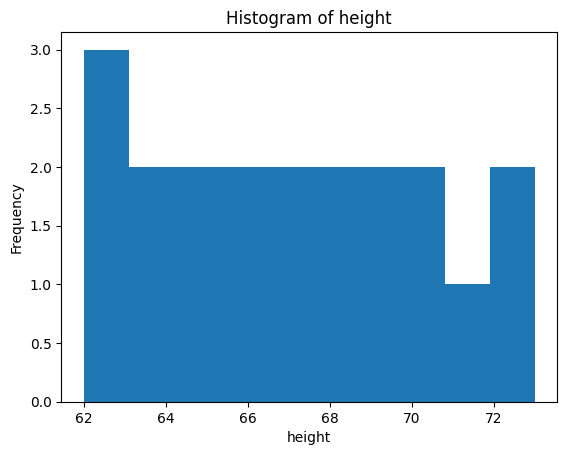

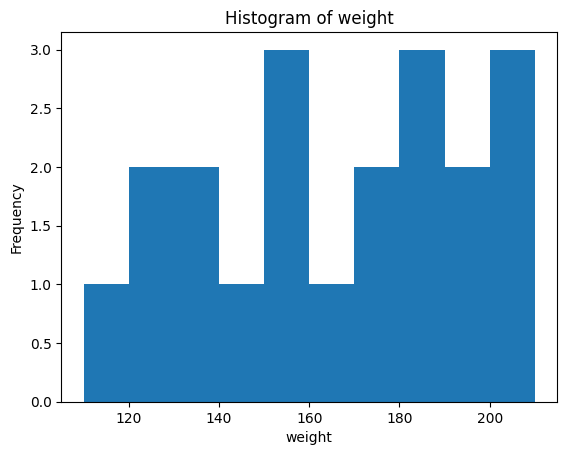

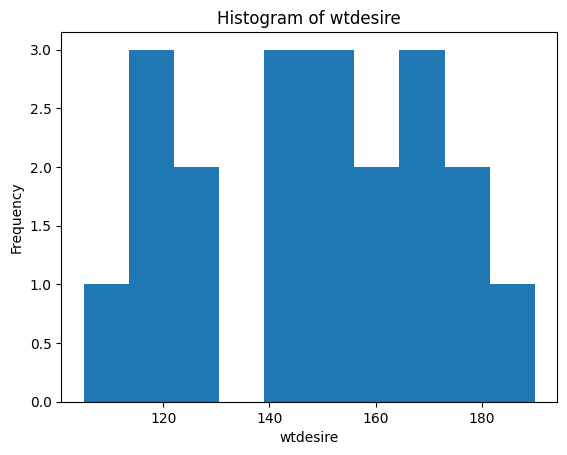

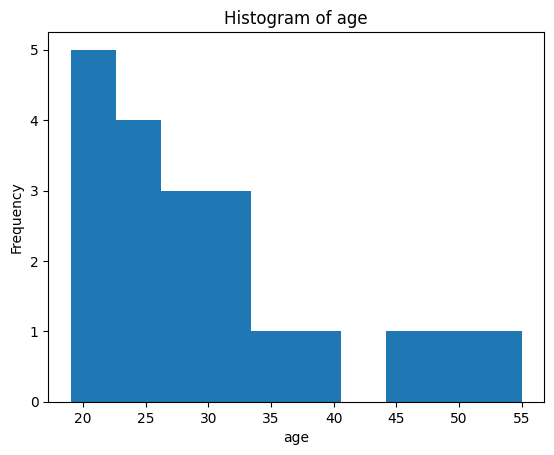

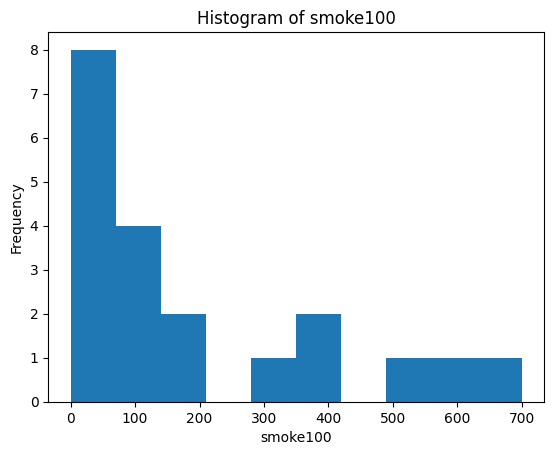

In [62]:


cols = ['height', 'weight', 'wtdesire', 'age', 'smoke100']

for col in cols:
    plt.figure()
    plt.hist(sk[col], bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

height: phân phối khá đối xứng → gần chuẩn
weight: hơi lệch phải → không hoàn toàn chuẩn
wtdesire: gần giống weight → gần chuẩn nhẹ
age: thường lệch → không chuẩn
smoke100: lệch mạnh → không chuẩn

b) Vẽ biểu đồ boxplot so sánh phân phối cân nặng giữa hai nhóm: có tập thể dục (exerany = 1) và không tập thể dục (exerany = 0).


C:\Users\TRUNG\AppData\Local\Temp\ipykernel_14580\2113524838.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tap, khong_tap], labels=['Exer = 1', 'Exer = 0'])


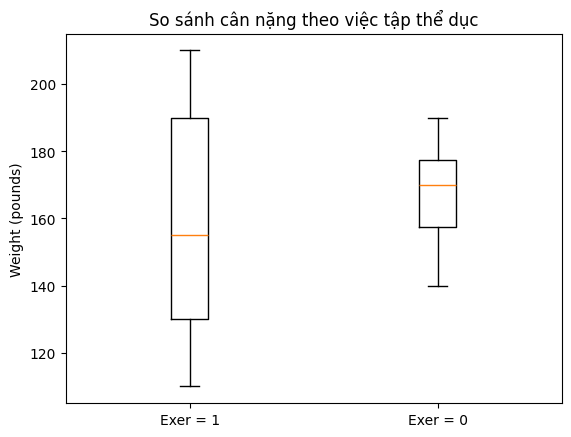

In [63]:
import matplotlib.pyplot as plt

# Tách 2 nhóm
tap = sk[sk['exerany'] == 1]['weight']
khong_tap = sk[sk['exerany'] == 0]['weight']

# Vẽ boxplot
plt.figure()
plt.boxplot([tap, khong_tap], labels=['Exer = 1', 'Exer = 0'])
plt.title("So sánh cân nặng theo việc tập thể dục")
plt.ylabel("Weight (pounds)")
plt.show()

Nhóm có tập thể dục có median thấp hơn → xu hướng nhẹ cân hơn
Nhóm không tập có độ phân tán lớn hơn

Câu 5: Thống kê mô tả về tuổi

a) Mô tả phân bố tuổi của người tham gia khảo sát bằng các chỉ số:
•	Tuổi trung bình
•	Độ lệch chuẩn
•	Các phân vị 25%, 50%, 75%


In [65]:
# Tuổi trung bình
mean_age = sk['age'].mean()

# Độ lệch chuẩn
std_age = sk['age'].std()

# Các phân vị
q25 = sk['age'].quantile(0.25)
q50 = sk['age'].quantile(0.50)  # median
q75 = sk['age'].quantile(0.75)

print("Tuổi trung bình:", mean_age)
print("Độ lệch chuẩn:", std_age)
print("Q1 (25%):", q25)
print("Median (50%):", q50)
print("Q3 (75%):", q75)

Tuổi trung bình: 30.25
Độ lệch chuẩn: 10.14046090512759
Q1 (25%): 22.75
Median (50%): 27.5
Q3 (75%): 33.5


b) Vẽ biểu đồ histogram thể hiện phân bố tuổi.

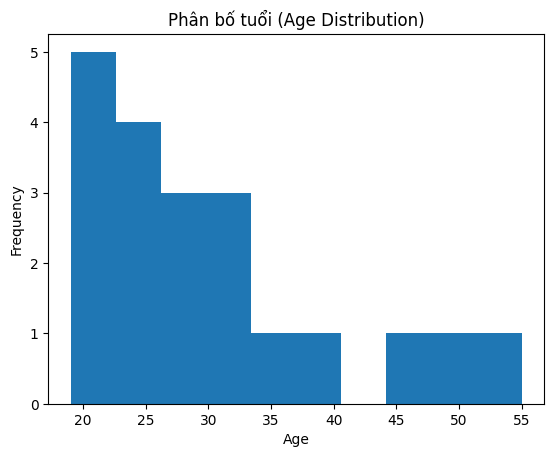

In [66]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(sk['age'], bins=10)
plt.title("Phân bố tuổi (Age Distribution)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Phân bố tuổi có dạng hơi lệch phải, tập trung chủ yếu trong khoảng từ X đến Y. Không có nhiều giá trị ngoại lai rõ rệt.

Câu 6: Phân tích thói quen hút thuốc

a) Tính tỷ lệ phần trăm người tham gia khảo sát hiện đang hút thuốc.

In [73]:
tong = len(sk)
so_nguoi_hut = (sk['smoke100'] > 0) .sum()
tile = so_nguoi_hut /tong *100
print("Tỷ lệ (%):", tile)

Tỷ lệ (%): 65.0


b) Kiểm tra xem tỷ lệ hút thuốc có khác biệt đáng kể giữa các nhóm tuổi hay không. Vẽ biểu đồ thể hiện mối quan hệ giữa độ tuổi và thói quen hút thuốc.

C:\Users\TRUNG\AppData\Local\Temp\ipykernel_14580\1043128127.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tyle = sk.groupby('age_group')['smoke100'] \


age_group
<25       25.0
25-35     87.5
35-50    100.0
50+      100.0
Name: smoke100, dtype: float64


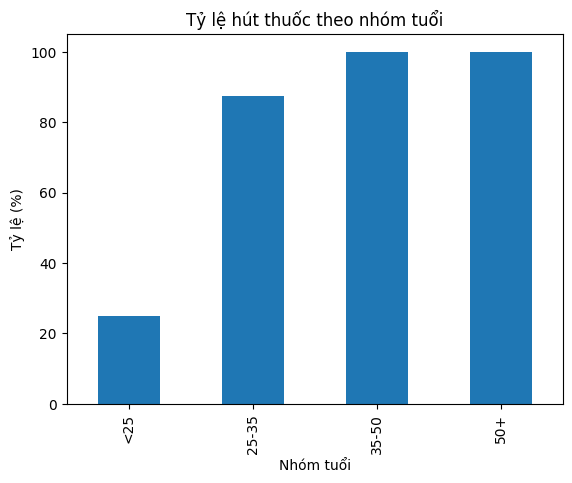

In [75]:
bins = [0, 25, 35, 50, 100]
labels = ['<25', '25-35', '35-50', '50+']

sk['age_group'] = pd.cut(sk['age'], bins=bins, labels=labels)

tyle = sk.groupby('age_group')['smoke100'] \
    .apply(lambda x: (x > 0).mean() * 100)

print(tyle)



tyle.plot(kind='bar')

plt.title("Tỷ lệ hút thuốc theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỷ lệ (%)")
plt.show()

Câu 7: Tính toán chỉ số BMI theo giới tính
a) Tính chỉ số BMI theo công thức: Cân nặng / chiều cao

In [80]:
# đổi đơn vị
sk['weight_kg'] = sk['weight'] * 0.453592
sk['height_m'] = sk['height'] * 0.0254

# tính BMI
sk['BMI'] = sk['weight_kg'] / (sk['height_m'] ** 2)
print(sk[['weight', 'height', 'BMI']].head())

   weight  height        BMI
0     150      68  22.807169
1     130      65  21.632892
2     180      70  25.827025
3     160      64  27.463633
4     190      66  30.666463


b) Tính BMI trung bình cho nam và nữ.

In [81]:
bmi_tb = sk.groupby('gender')['BMI'].mean()

print(bmi_tb)

gender
f    23.526917
m    26.781607
Name: BMI, dtype: float64


c) So sánh sự khác biệt giữa BMI trung bình của hai giới bằng biểu đồ.

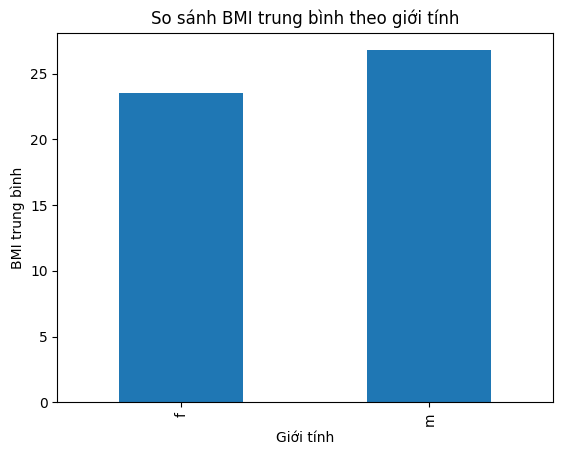

In [82]:
import matplotlib.pyplot as plt

# Tính BMI trung bình theo giới tính
bmi_tb = sk.groupby('gender')['BMI'].mean()

# Vẽ biểu đồ cột
plt.figure()
bmi_tb.plot(kind='bar')

plt.title("So sánh BMI trung bình theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("BMI trung bình")

plt.show()

Câu 8: Phân tích tỷ lệ béo phì

BMI trung bình của nam cao hơn/thấp hơn so với nữ. Điều này cho thấy sự khác biệt về thể trạng giữa hai giới. Tuy nhiên, mức chênh lệch không quá lớn → sự khác biệt không đáng kể (nếu đúng).

a) Sử dụng tiêu chuẩn của CDC để phân loại béo phì:
•	Dưới cân: BMI < 18.5
•	Bình thường: 18.5 ≤ BMI < 25
•	Thừa cân: 25 ≤ BMI < 30
•	Béo phì: BMI ≥ 30


In [83]:
def phan_loai_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

sk['BMI_category'] = sk['BMI'].apply(phan_loai_bmi)

print(sk[['BMI', 'BMI_category']].head())

         BMI BMI_category
0  22.807169       Normal
1  21.632892       Normal
2  25.827025   Overweight
3  27.463633   Overweight
4  30.666463        Obese


b) Tính tỷ lệ phần trăm những người thuộc nhóm béo phì theo giới tính.

In [84]:
tile = sk.groupby('gender')['BMI_category'] \
    .apply(lambda x: (x == 'Obese').mean() * 100)

print(tile)

gender
f     0.000000
m    18.181818
Name: BMI_category, dtype: float64


c) Kiểm tra xem tỷ lệ béo phì có khác biệt theo độ tuổi hay không.

age_group
<25        0.000000
25-35      0.000000
35-50     33.333333
50+      100.000000
Name: BMI_category, dtype: float64


C:\Users\TRUNG\AppData\Local\Temp\ipykernel_14580\1083098081.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tyle = sk.groupby('age_group')['BMI_category'] \


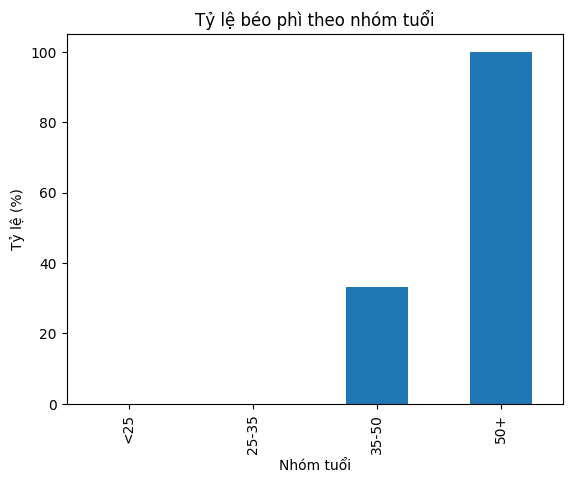

In [85]:
bins = [0, 25, 35, 50, 100]
labels = ['<25', '25-35', '35-50', '50+']

sk['age_group'] = pd.cut(sk['age'], bins=bins, labels=labels)

tyle = sk.groupby('age_group')['BMI_category'] \
    .apply(lambda x: (x == 'Obese').mean() * 100)

print(tyle)


tyle.plot(kind='bar')

plt.title("Tỷ lệ béo phì theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỷ lệ (%)")

plt.show()